# MODELO DE HOPFIELD. REDES NEURONALES 

## Animación de la evolución de la red

Hemos realizado 51 pasos Monte Carlo.
Estamos trabajando con 400 neuronas


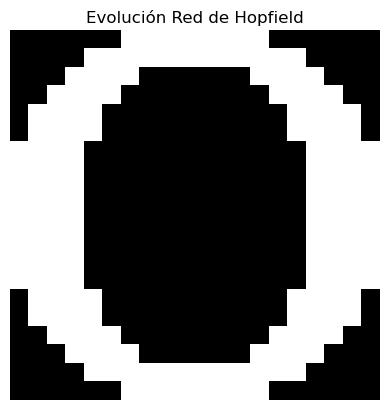

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- CONFIGURACIÓN ---
n =20 # Tamaño de la red
archivo = "configuraciones_MC.txt" 

# Leemos los datos
# Cada fila del archivo es un paso de Monte Carlo completo
datos = np.loadtxt(archivo)

num_frames = datos.shape[0]  # Número de líneas = Número de pasos MC
L = datos.shape[1]           # Número de columnas = L (total de neuronas)

print(f"Hemos realizado {num_frames} pasos Monte Carlo.")
print(f"Estamos trabajando con {L} neuronas")


# Convertimos cada fila de L elementos en una matriz de n x n
frames = datos.reshape((num_frames, n,n))

# --- ANIMACIÓN ---
fig, ax = plt.subplots()

# Mostramos el primer frame
im = ax.imshow(frames[0], cmap='binary', interpolation='nearest')
ax.axis('off')
ax.set_title("Evolución Red de Hopfield")

def actualizar(i):
    # Actualiza la imagen con el frame número i
    im.set_data(frames[i])
    return [im]

# Creamos la animación
ani = FuncAnimation(fig, actualizar, frames=num_frames, interval=500, blit=True)

# Guardamos como GIF
#ani.save('patron_x.gif', writer='pillow', fps=1)

# Mostramos en pantalla
HTML(ani.to_jshtml())

## Representación del solapamiento en función del tiempo (Pasos MC)

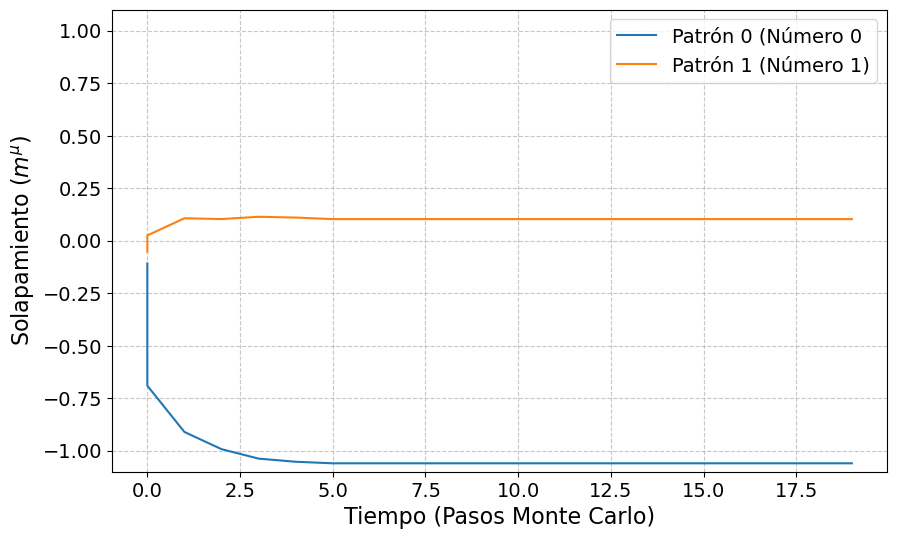

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Cargamos los datos
datos = np.loadtxt('solap_patrones0_1_Temperatura0_02.txt')

# Cogemos la primera columna como el eje X que va a ser el tiempo en pasos MC
pasos_mc = datos[:, 0]


plt.figure(figsize=(10, 6))

# Graficamos cada solapamiento por separado
plt.plot(pasos_mc, datos[:, 1], marker='', linestyle='-', label='Patrón 0 (Número 0')
plt.plot(pasos_mc, datos[:, 2], marker='', markersize= 3 , linestyle='-', label='Patrón 1 (Número 1)')
#plt.plot(pasos_mc, datos[:, 3], marker='o', linestyle='-', label='Patrón 2')

# Configuramos los ejes
#plt.title('Evolución de los Solapamientos vs Tiempo (MCS)')
plt.xlabel('Tiempo (Pasos Monte Carlo)', fontsize=16)
plt.ylabel(r'Solapamiento ($m^\mu$)', fontsize=16)
plt.ylim(-1.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)

# Guardamos el plot
#plt.savefig('solapamiento_0_1_02.png', dpi=300)


plt.show()

### Representación del solapamiento junto con el estado final de la red

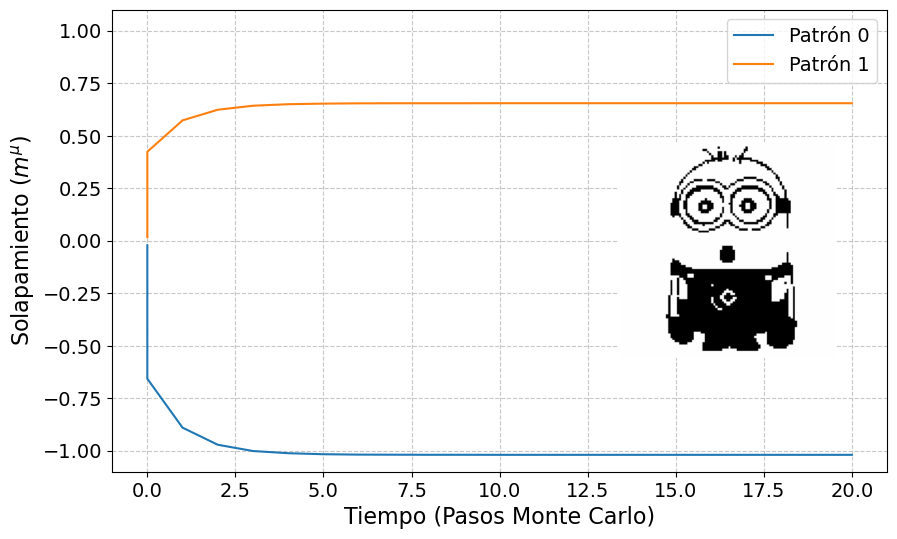

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Cargamos los datos
datos = np.loadtxt('solap_minion_002.txt')

# Cogemos la primera columna como el eje X que va a ser el tiempo en pasos MC
pasos_mc = datos[:, 0]


fig, ax = plt.subplots(figsize=(10, 6))

# Graficamos cada solapamiento por separado 
ax.plot(pasos_mc, datos[:, 1], marker='', linestyle='-', label='Patrón 0')
ax.plot(pasos_mc, datos[:, 2], marker='', markersize=3, linestyle='-', label='Patrón 1')
# ax.plot(pasos_mc, datos[:, 3], marker='o', linestyle='-', label='Patrón 2 (Número 7)')

# Configuramos los ejes
ax.set_xlabel('Tiempo (Pasos Monte Carlo)', fontsize=16)
ax.set_ylabel(r'Solapamiento ($m^\mu$)', fontsize=16)
ax.set_ylim(-1.1, 1.1)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=14)

# --- Metemos la imagen ---

# Cargamos la imagen
img = plt.imread('002_minion.png')

# Creamos los ejes para la imagen dentro de la figura
ax_ins = fig.add_axes([0.56, 0.3, 0.36, 0.36]) # [derecha, arriba, ancho, alto] 

# Mostramos la imagen y quitamos los números de los ejes
ax_ins.imshow(img)
ax_ins.axis('off')

# Guardamos la imagen
#plt.savefig('minion_002.png', dpi=300)

# Mostrar el resultado
plt.show()

### Representación del solapamiento en función del tiempo para diferentes temperaturas

Para no saturar la cantidad de archivos txt que subo al repositorio esta celda la dejo a disposición del lector, para compilar un patrón para diferentes temperaturas y graficar asi la curva de solapamiento para todos.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


archivos = ['solap_tigre_01_ruido03.txt','solap_tigre_02_ruido03.txt','solap_tigre_05_ruido03.txt', 'solap_tigre_1_ruido03.txt', 'solap_tigre_2_ruido03.txt', 'solap_tigre_5_ruido03.txt']
etiquetas = [ 'T=0.01', 'T=0.02', 'T=0.05', 'T=0.1', 'T=0.2', 'T=0.5']

plt.figure(figsize=(10, 6))


# Leemos todos los archivos y guardamos todos los datos
for i, nombre_archivo in enumerate(archivos):
    datos = np.loadtxt(nombre_archivo)
    pasos_mc = datos[:, 0]
    solapamiento = datos[:, 1] 
    
    plt.plot(pasos_mc, solapamiento, linestyle='-', label=etiquetas[i])

#plt.title('Evolución de la red (T=0.1)', fontsize=18)
plt.xlabel('Tiempo (Pasos Monte Carlo)', fontsize=16)
plt.ylabel(r'Solapamiento ($m^\mu$)', fontsize=16)

plt.ylim(-0.2, 1.1)
plt.xlim(-0.5, 21)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)



#plt.savefig('solapamiento_tigre_ruido30.png', dpi=300)
plt.show()

### Solapamiento en función de la temperatura (promedio de varias simulaciones)

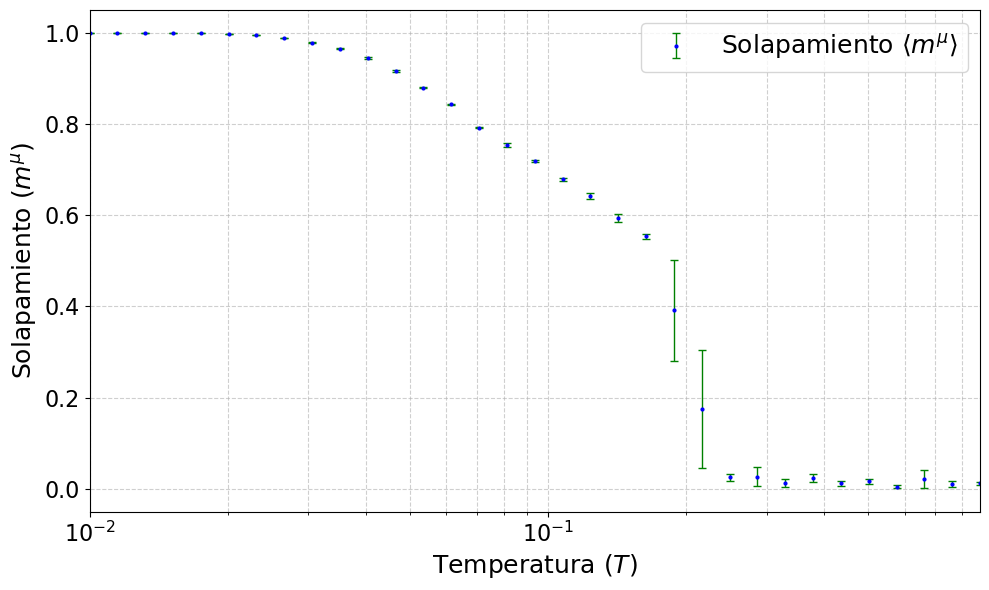

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Creamos una lista con los archivos (para hacer el promedio de todas las simulaciones hechas)
archivos = ['barrido_temperatura.txt', 'barrido_temperatura_1.txt', 'barrido_temperatura_2.txt']

datos_lista = []

# Cargamos los datos de cada archivo
for nombre in archivos:
    data = np.loadtxt(nombre)
    datos_lista.append(data[:, 1])  # Guardamos solo la columna del solapamiento

# Convertimos a un array de numpy para trabajar de manera más fácil
solapamientos = np.array(datos_lista)

# La temperatura es la misma para todos asi que tomamos del primer archivo
temperatura = np.loadtxt(archivos[0])[:, 0]

# Calculamos la media y la desviación típica
media_m = np.mean(solapamientos, axis=0)
std_m = np.std(solapamientos, axis=0)

# --- GRÁFICA-----
plt.figure(figsize=(10, 6))


plt.errorbar(temperatura, media_m, yerr=std_m, fmt='o', markersize=2,  color='blue', ecolor='green', elinewidth=1, capsize=3, 
             label=r'Solapamiento $\langle m^\mu \rangle$')

# Usamos la escala logaritmica en el eje x
plt.xscale('log')


plt.xlabel('Temperatura ($T$)', fontsize=18)
plt.ylabel(r'Solapamiento ($m^\mu$)', fontsize=18)

# Ajustamos los límites al máximo y mínimo de temperatura
plt.xlim( min(temperatura), max(temperatura))
plt.ylim(-0.05, 1.05)


plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.legend(fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()

#plt.savefig('solapamiento_temperatura.png', dpi=300)
plt.show()

## Capacidad de almacenamiento

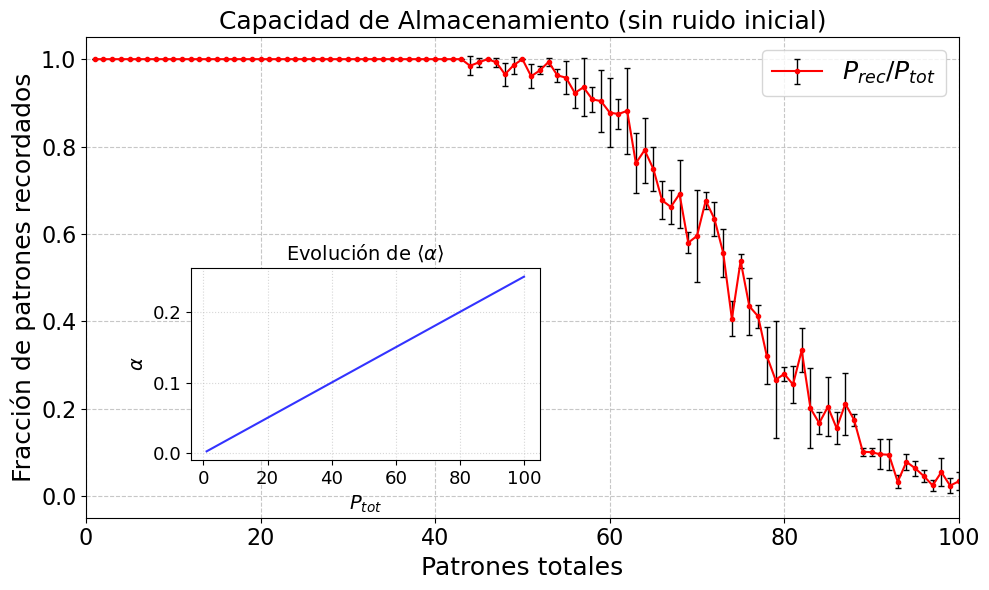

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Guardamos los archivos en una lista
archivos = ['datos_memoria_100_sin_ruido.txt',  'datos_memoria_100_sin_ruido_1.txt', 'datos_memoria_100_sin_ruido_2.txt']

# Creamos las listas donde vamos a guardar las variables y las inicializamos a vacío
fracciones_lista = []
alphas_lista = []

# Cargamos los datos
# Recordar que la Columna 0: p_totales, Columna 1: fraccion, Columna 2: alpha

for nombre in archivos:
    data = np.loadtxt(nombre)
    fracciones_lista.append(data[:, 1])
    alphas_lista.append(data[:, 2])

# Cargamos p_totales 
p_totales = np.loadtxt(archivos[0])[:, 0]

# Convertimos a arrays para calcular la media y la desviación típica
fracciones = np.array(fracciones_lista)
alphas = np.array(alphas_lista)

# Media y desviacion:
media_fraccion = np.mean(fracciones, axis=0)
std_fraccion = np.std(fracciones, axis=0)

media_alpha = np.mean(alphas, axis=0)
std_alpha = np.std(alphas, axis=0)

# ----GRÁFICA-----
fig, ax = plt.subplots(figsize=(10, 6))


ax.errorbar(p_totales, media_fraccion, yerr=std_fraccion, fmt='o-',  markersize=3, color='red', ecolor='black', elinewidth=1, 
            capsize=2, label=r'$P_{rec} / P_{tot}$')

ax.set_title('Capacidad de Almacenamiento (sin ruido inicial)', fontsize=18)
ax.set_xlabel('Patrones totales', fontsize=18)
ax.set_ylabel('Fracción de patrones recordados', fontsize=18)
ax.legend(fontsize=18, loc='upper right')
ax.set_xlim(0, max(p_totales))
ax.set_ylim(-0.05, 1.05)
plt.tick_params(axis='both', which='major', labelsize=16)
ax.grid(True, linestyle='--', alpha=0.7)

# --- INSET ---
ax_inset = ax.inset_axes([0.12, 0.12, 0.4, 0.4]) 

# Inset con barras de error para alpha
ax_inset.errorbar(p_totales, media_alpha, yerr=std_alpha, fmt='-', color='blue', ecolor='lightblue', alpha=0.8, lw=1.5)

ax_inset.set_xlabel('$P_{tot}$', fontsize=14)
ax_inset.set_ylabel(r'$\alpha$', fontsize=14)
ax_inset.set_title(r'Evolución de $\langle \alpha \rangle$', fontsize=14)
ax_inset.tick_params(axis='both', which='major', labelsize=13)
ax_inset.grid(True, linestyle=':', alpha=0.5)


#plt.savefig('capacidad_almacenamiento_sinruido.png', dpi=300)
plt.tight_layout()

plt.show()